# Tensor-chain Born machine — constraint training + regularizers

A linear tensor train (matrix product state) as a **Born machine**,
`p(x) = ψ(x)² / Z`, over the chain `A → B → C` on `[0, 100]` (continuous
variables, **discretised** for the network).

**No dataset.** We minimise a squared-error loss on the *local* marginal /
conditional constraints of `case_chain_propagation` (spec §6):

    P(A>50)=0.70
    P(B>50|A>50)=0.80,  P(B<50|A<50)=0.90
    P(C>50|B>50)=0.80,  P(C<50|B<50)=0.90

The **propagated** marginals `P(B>50)=0.59`, `P(C>50)=0.513` are *not* fit
directly — they emerge (law of total probability) if the local constraints hold.

In [2]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import numpy as np

from calibrated_response.tn import TensorChain, ContinuousVar, plot_pairwise, losses as L
from examples.maxent_tests.tn_chain_demo import chain_constraints, EXPECTED

# names = ["A", "B", "C"]
# vars = [ContinuousVar("A", 0, 100, 20),
#         ContinuousVar("B", 0, 100, 20),
#         ContinuousVar("C", 0, 100, 20)]
nvars = 5
names = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")[:nvars]
vars = [ContinuousVar(name, 0, 100, 20) for name in names]

model_r = TensorChain(vars, bond_dim=6, kind="born")
cons_r = chain_constraints(model_r, n_var=nvars)

### Fit with a regularizer (edit me)

The 5 constraints pin only the aggregate `>50` / `<50` half-masses; the
within-half shape is free and, unregularised, collapses onto a few spiky bins.
This cell is the knob: **uncomment one** regularizer, run, and read the propagated
marginals plus the exact pairwise plot. The sweep further down compares them all
side by side.

In [ ]:
model_r = TensorChain(vars, bond_dim=6, kind="born")
cons_r = chain_constraints(model_r)

# --- pick ONE regularizer by uncommenting (see the sweep below for how each behaves) ---
reg = []
reg += [(L.amplitude_roughness(order=2), 1.0)]   # <psi|L|psi>/Z : gauge-invariant curvature of psi (smothing_notes.md)
# reg = [("curvature", 5.0)]                     # curvature of each marginal p(x_i) (gauge-invariant)
# reg += [("core_tv", 3.0)]                       # first-diff on the raw cores (cheap, gauge-dependent)
# reg = [("entropy", 0.02)]                      # push marginals toward uniform (adjacency-blind)
# reg = [(L.projection_entropy(n_dirs=3, n_grid=81), 0.05)]  # de-bunch the a.X projections
# reg = []                                       # baseline: no regularizer (spiky)

params_r, _ = model_r.optimize(L.combined_loss(model_r, cons_r, reg),
                               backend="adam", steps=2000, lr=3e-2, seed=0)
print("propagated marginals with regularizer:")
for i, nm in enumerate(names):
    print(f"  P({nm}>50) = {model_r.prob_gt(params_r, i, 50.0):.3f}")
_FIG = plot_pairwise(model_r, params_r, threshold=50)[0]

### Train on the constraints (Adam, no data) — baseline

In [ ]:
model = TensorChain(vars, bond_dim=6, kind="born")
constraints = chain_constraints(model)
params, history = model.optimize(model.constraint_loss(constraints),
                                 backend="adam", steps=2000, lr=3e-2, seed=0)
print(f"final constraint loss = {history[-1]:.2e}")

for cst in constraints:
    if cst[0] == "prob":
        _, ev, tg = cst
        print(f"  P(A>50)        = {float(model.event_prob(params, ev)):.3f}   (target {tg:.2f})")
    else:
        _, ev, gv, tg = cst
        lbl = "B|A" if 1 in ev else "C|B"
        print(f"  P({lbl} constraint) = {float(model.cond_prob(params, ev, gv)):.3f}   (target {tg:.2f})")

final constraint loss = 2.75e-12
  P(A>50)        = 0.700   (target 0.70)
  P(B|A constraint) = 0.800   (target 0.80)
  P(B|A constraint) = 0.900   (target 0.90)
  P(C|B constraint) = 0.800   (target 0.80)
  P(C|B constraint) = 0.900   (target 0.90)


Propagated marginals (**not** fit directly) — read exactly off the network:

In [ ]:
for i, nm in enumerate(names):
    print(f"  P({nm}>50) = {model.prob_gt(params, i, 50.0):.3f}   (target {EXPECTED[nm]:.3f})")

  P(A>50) = 0.700   (target 0.700)
  P(B>50) = 0.590   (target 0.590)
  P(C>50) = 0.513   (target 0.513)


### Pairwise marginals — baseline

Every panel is an **exact** contraction of the network (`site_marginal` /
`pair_marginal`), not a sample histogram. Constraints are met, but the
under-determined part is **spiky**: within each `>50` / `<50` half the mass
collapses onto a few bins (contrast the regularised showcase above).

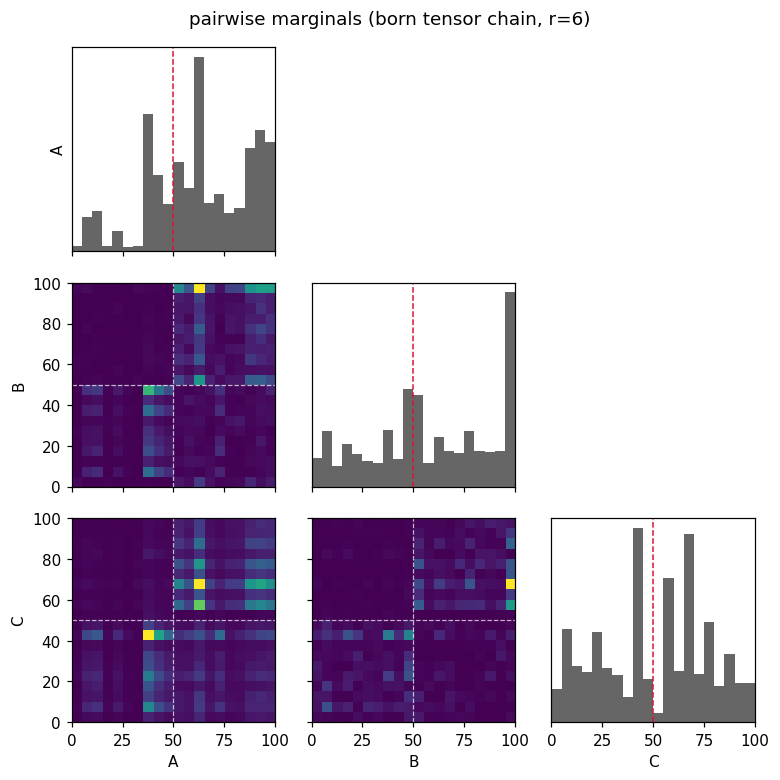

In [ ]:
_FIG = plot_pairwise(model, params, threshold=50)[0]

## Regularizing the under-determined part

`calibrated_response.tn.losses` offers several regularizers that act on the
model's exact per-site marginals, the projected distribution, or the cores. We
sweep them and report the constraint residual, the propagated marginals, and a
spikiness gauge — `perplexity` = effective #bins occupied (≈20 is fully spread,
≈1 is a spike).

In [ ]:
def evaluate(regs, tag):
    m = TensorChain(vars, bond_dim=6, kind="born")
    cons = chain_constraints(m)
    p, _ = m.optimize(L.combined_loss(m, cons, regs), backend="adam", steps=1500, lr=3e-2, seed=0)
    resid = float(m.constraint_loss(cons)(p)) ** 0.5
    pb, pc = m.prob_gt(p, 1, 50.0), m.prob_gt(p, 2, 50.0)
    ppl = L.marginal_perplexity(m, p)
    print(f"{tag:26} resid {resid:.4f}   P(B>50) {pb:.3f}  P(C>50) {pc:.3f}   perplexity {ppl:5.1f}/20")

print(f"{'regularizer':26} {'constraint':11} propagated          spread")
evaluate([], "none")
evaluate([("entropy", 0.02)], "entropy")
evaluate([("coverage", 0.05)], "coverage")
evaluate([("curvature", 5.0)], "curvature (marginal)")
evaluate([("core_tv", 3.0)], "core_tv (raw weights)")
evaluate([(L.amplitude_roughness(order=2), 8.0)], "amplitude_roughness")
evaluate([(L.projection_entropy(n_dirs=3, n_grid=81), 0.05)], "projection_entropy")

regularizer                constraint  propagated          spread
none                       resid 0.0000   P(B>50) 0.590  P(C>50) 0.513   perplexity  15.5/20
entropy                    resid 0.0038   P(B>50) 0.587  P(C>50) 0.511   perplexity  19.4/20
coverage                   resid 0.0098   P(B>50) 0.582  P(C>50) 0.507   perplexity  19.4/20
curvature (marginal)       resid 0.0000   P(B>50) 0.590  P(C>50) 0.513   perplexity  19.1/20
core_tv (raw weights)      resid 0.0122   P(B>50) 0.579  P(C>50) 0.501   perplexity  18.7/20
amplitude_roughness        resid 0.0061   P(B>50) 0.591  P(C>50) 0.516   perplexity  14.6/20
projection_entropy         resid 0.0150   P(B>50) 0.587  P(C>50) 0.510   perplexity  12.9/20


Three *smoothness* families appear here, and they differ in **what** they act on:

- **`curvature`** — squared second difference of each **marginal** `p(x_i)`. A
  gauge-invariant function of the density; the cleanest here (near-zero constraint
  cost, marginals fully spread).
- **`core_tv`** — first differences of the **raw cores**. Cheap (no contraction)
  and effective, but it acts on the *parameterisation*: under MPS gauge freedom the
  same `p` can have rougher or smoother cores, so this is only the true
  function-roughness in canonical form (see `smothing_notes.md`).
- **`amplitude_roughness`** — the faithful version of those notes for *global*
  (non-sweeping) training: the two-copy contraction `⟨ψ|Lᵢ|ψ⟩ / Z` with the
  roughness metric `L = DᵀD` inserted at site `i`. Being a pure function of the
  amplitude `ψ`, it is **gauge-invariant** — it cannot be gauged away like the
  raw-core penalty — and per the notes' Born caveat it smooths `ψ`, not `p = ψ²`.
  Its null space is constants + linear ramps, so it is a *milder* smoother than the
  marginal curvature (perplexity plateaus ~17, not ~19), but it is the honest one
  when you are **not** running a canonicalising ALS/DMRG sweep. `order=1` penalises
  slope instead of curvature.

## Projected distributions — `P(a·X)` and `P(a·X < c)`

Beyond per-variable marginals, the chain computes the full distribution of any
**weighted sum** `Y = a·X` exactly, by carrying the running partial-sum
distribution as an extra axis on the transfer (`projection_distribution`). From it
we read the CDF `P(a·X < c)` (`prob_lt`) and, as a regularizer, the **entropy** of
`a·X` (`losses.projection_entropy`, one of the sweep rows above). Note the summed
projections here are already fairly spread — summing several variables is
CLT-like, so it smooths away the per-variable spikiness.

E[A+B+C] = 171.4   sd = 88.2
P(A+B+C < 150) = 0.425   (exact up to grid resolution)


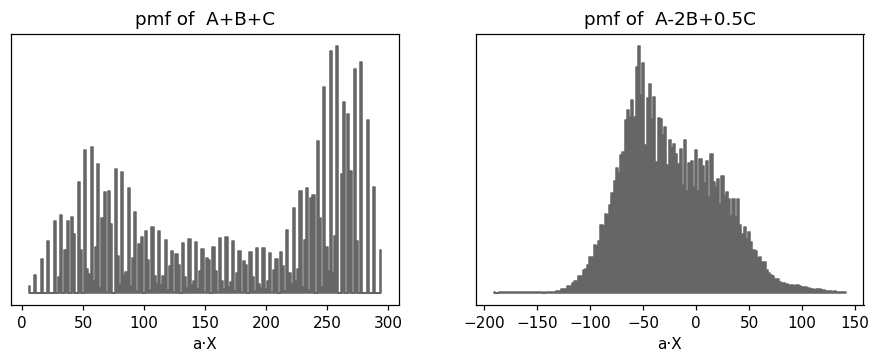

In [ ]:
import matplotlib.pyplot as plt

directions = {"A+B+C": np.array([1., 1., 1.]),
              "A-2B+0.5C": np.array([1., -2., 0.5])}
fig, axes = plt.subplots(1, len(directions), figsize=(10, 3.2))
for ax, (lbl, a) in zip(axes, directions.items()):
    y, pmf = model_r.projection_distribution(params_r, a, n_grid=161)
    ax.fill_between(y, pmf, step="mid", color="0.4")
    ax.set_title(f"pmf of  {lbl}")
    ax.set_xlabel("a·X"); ax.set_yticks([])
_FIG = fig

# the projected CDF as a direct query
a, c = np.array([1., 1., 1.]), 150.0
mean, var = (float(x) for x in model_r.linear_moments(params_r, a))
print(f"E[A+B+C] = {mean:.1f}   sd = {var**0.5:.1f}")
print(f"P(A+B+C < {c:.0f}) = {model_r.prob_lt(params_r, a, c):.3f}   "
      f"(exact up to grid resolution)")

### Note on representation

The cores store **linear-space amplitudes**, not probabilities and not
log-probabilities — only the full contraction `ψ(x)` has meaning, and
`p(x) = ψ(x)² / Z`. Log-space appears *only* as running-norm stabilisation inside
the contraction. Every constraint and every plotted marginal is an exact
contraction with the queried sites open and the rest summed out, so both the
training loss and the diagnostics are defined directly on the model's marginals,
with no samples involved.